# Initial Data Setup

In [547]:
# Importing Libraries

import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
import plotly.express as px
import warnings
# from google.colab import drive
warnings.simplefilter(action='ignore', category=FutureWarning)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, auc
from sklearn.metrics import PrecisionRecallDisplay
import lightgbm as lgb
import xgboost as xgb

from sklearn.model_selection import RandomizedSearchCV
import shap

In [3]:
# # Reading the files
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive
# %cp application_record.csv /content/application_record.csv
# %cp credit_record.csv /content/credit_record.csv
# %cd /content/

In [224]:
appl_df = pd.read_csv("application_record.csv")

credit_df = pd.read_csv("credit_record.csv")

In [225]:
# Printing the sample of the Application data

appl_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [226]:
# Printing the sample of the Credit data

credit_df.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [227]:
appl_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [228]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


## Visualizing the datasets

/var/folders/76/nkcqxhdn0fb82lc24hhzjy4c0000gn/T/ipykernel_7680/1348738920.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(
/var/folders/76/nkcqxhdn0fb82lc24hhzjy4c0000gn/T/ipykernel_7680/1348738920.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(
/var/folders/76/nkcqxhdn0fb82lc24hhzjy4c0000gn/T/ipykernel_7680/1348738920.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(
/var/folders/76/nkcqxhdn0fb82lc24hhzjy4c0000gn/T/ipykernel_7680/1348738920.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(
/var/folders/76/nkcqxhdn0fb82lc24hhzjy4c0000gn/T/ipy

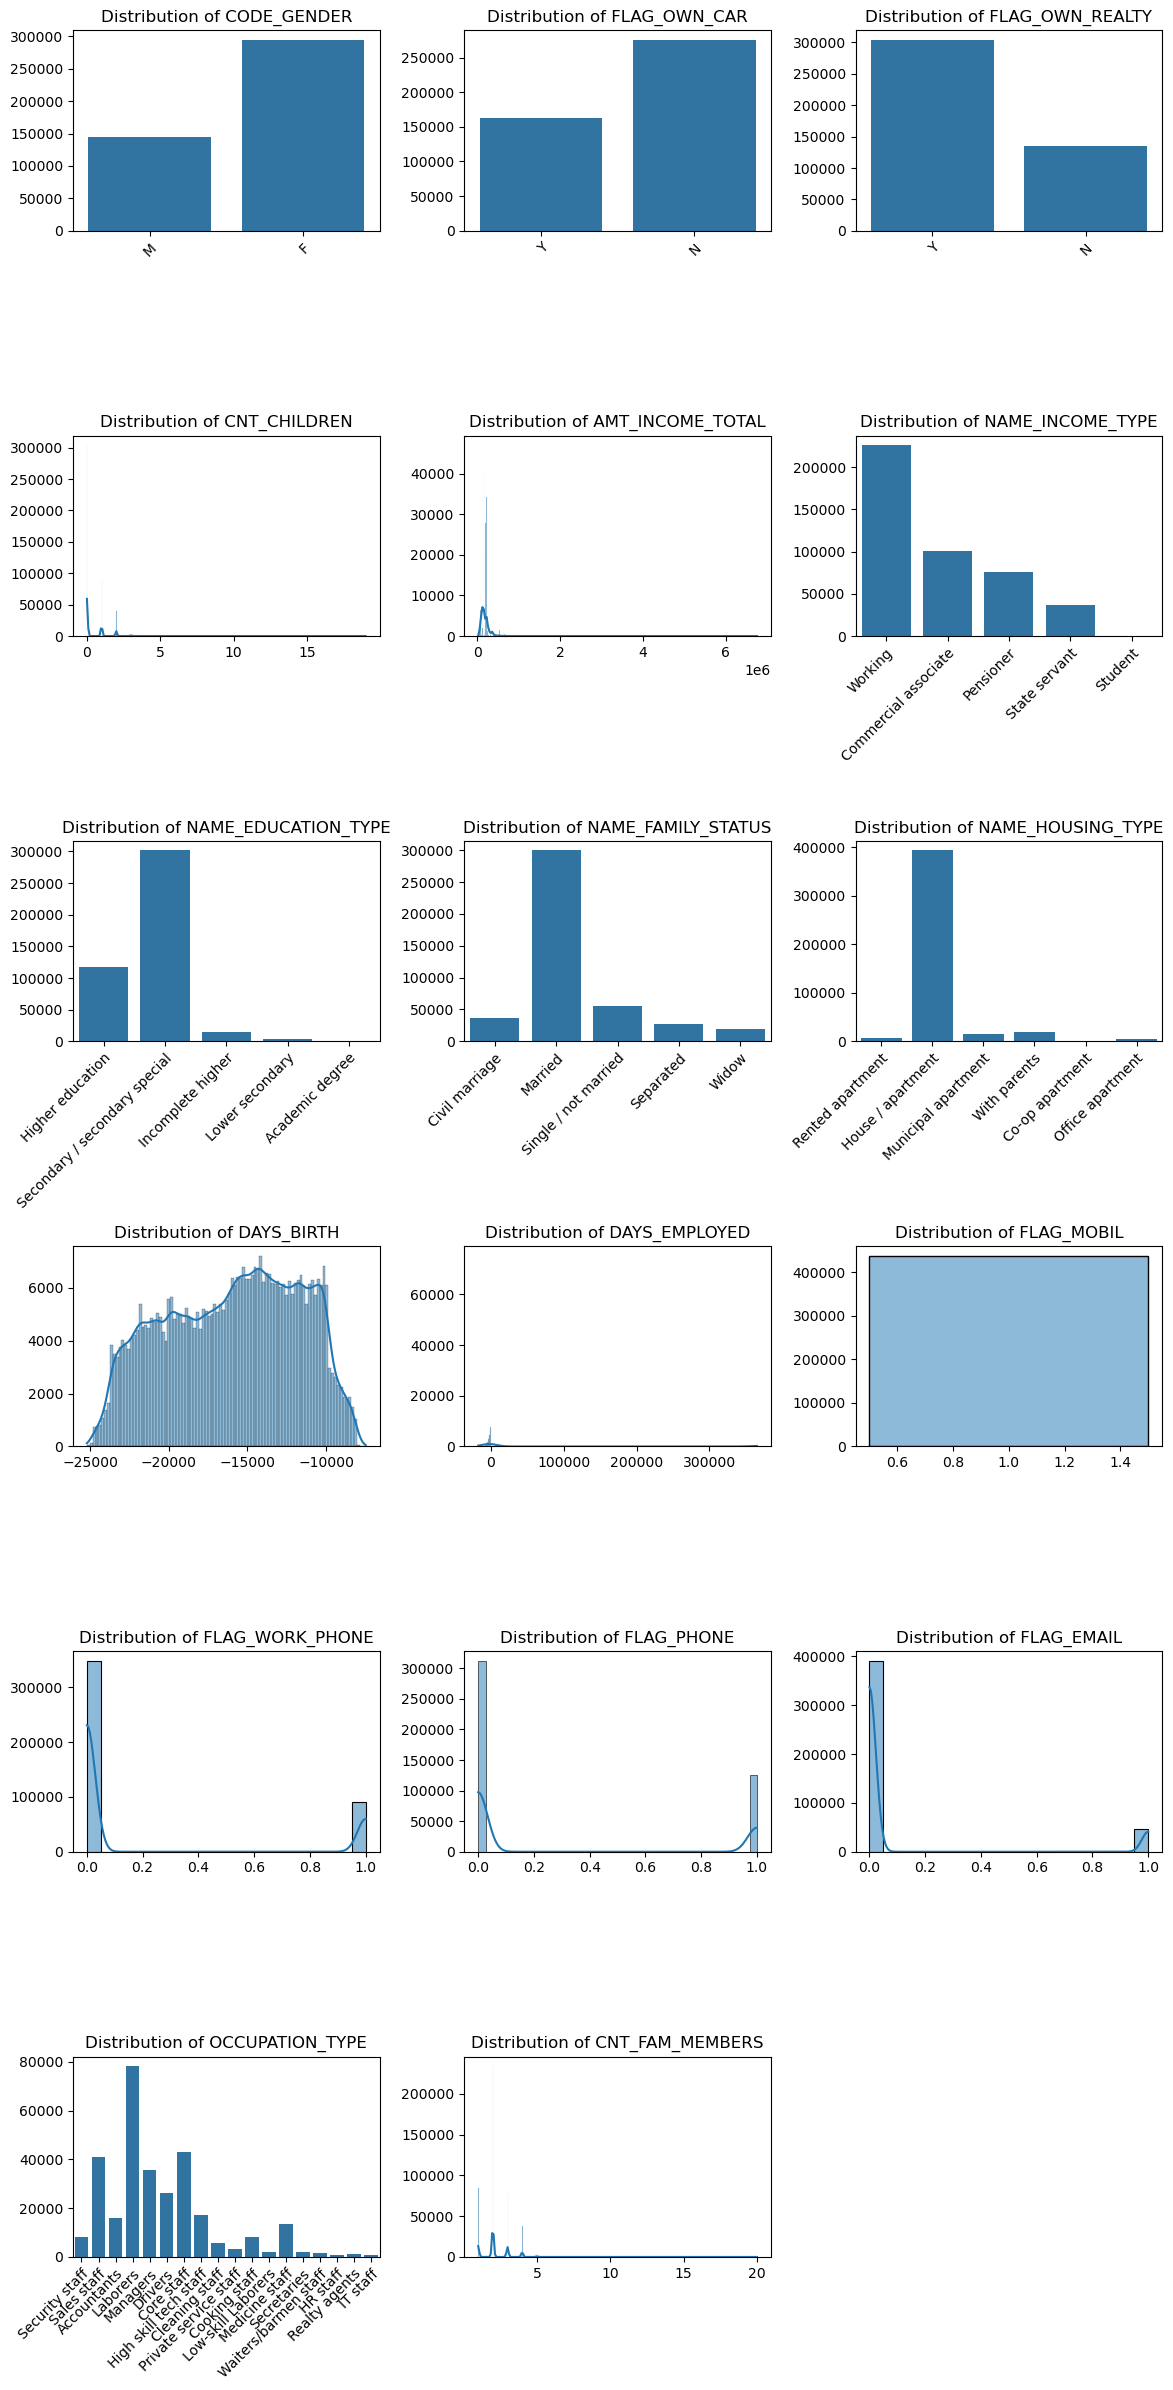

In [229]:
# Plotting distribution of the variables from the application data
all_vars = len(appl_df.columns) - 1  # Excluding 'ID'
num_cols = 3
num_rows = (
    all_vars // num_cols if all_vars % num_cols == 0 else all_vars // num_cols + 1
)
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, num_rows * 4))
fig.subplots_adjust(hspace=0.4, wspace=0.4)
axes = axes.flatten()
all_columns = appl_df.columns.drop("ID")
for i, col in enumerate(all_columns):
    if appl_df[col].dtype == "object":
        sns.countplot(x=appl_df[col], ax=axes[i])
        axes[i].set_xticklabels(
            axes[i].get_xticklabels(), rotation=45, ha="right", wrap=True
        )
    else:
        sns.histplot(appl_df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
if all_vars < len(axes):
    for i in range(all_vars, len(axes)):
        fig.delaxes(axes[i])
plt.tight_layout()

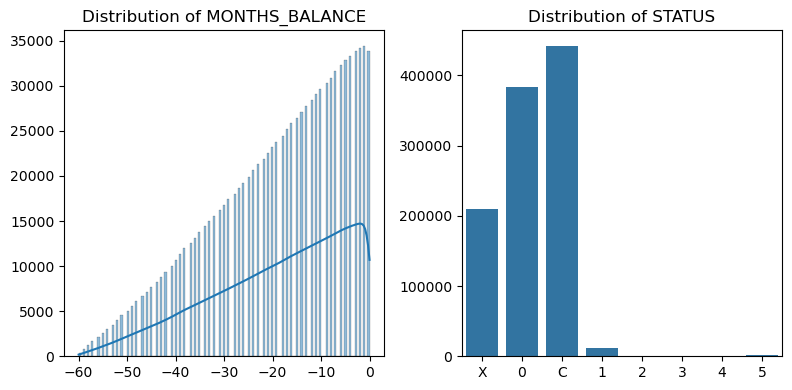

In [230]:
# Plotting distribution of the variables from the credit data
num_vars = (
    len(credit_df.select_dtypes(include=[np.number, "object"]).columns) - 1
)  # Excluding ID column
num_cols = 3
num_rows = (
    num_vars // num_cols if num_vars % num_cols == 0 else num_vars // num_cols + 1
)
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, num_rows * 4))
fig.subplots_adjust(hspace=0.4, wspace=0.4)
axes = axes.flatten()
for i, col in enumerate([col for col in credit_df.columns if col != "ID"]):
    if credit_df[col].dtype == "object" or credit_df[col].dtype == "bool":
        sns.countplot(x=credit_df[col], ax=axes[i])
    else:
        sns.histplot(credit_df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
if num_vars < len(axes):
    for i in range(num_vars, len(axes)):
        fig.delaxes(axes[i])
plt.tight_layout()

In [231]:
# Remove columns that are not needed for the analysis
appl_df = appl_df.drop(["FLAG_EMAIL",'FLAG_PHONE', 'FLAG_WORK_PHONE', 'FLAG_MOBIL'], axis=1)

In [232]:
# Total unique IDs vs Total Ids in the credit data
total_ids = credit_df.shape[0]
unique_ids = credit_df['ID'].nunique()
print(f"Total IDs: {total_ids}, Unique IDs: {unique_ids}")

Total IDs: 1048575, Unique IDs: 45985


In [233]:
# As multiple records exist for the same ID in the credit data, we will create a new status column that will indicate whether the customer has ever been delinquent or not. If the customer has ever been delinquent, we will mark them as 1, otherwise 0.
# threshold is greater than 1 meaning if they had a status of 1 or more at any point, they are considered delinquent.

credit_df["STATUS"] = credit_df["STATUS"].replace({"C": -1, "X": -1}).astype(int)
credit_df["delinquent"] = credit_df["STATUS"].apply(lambda x: 1 if x > 1 else 0)
credit_df = credit_df.groupby('ID').agg(
    delinquent=('delinquent', 'max'),
    lowest_balance_months=('MONTHS_BALANCE', 'min')
).reset_index()

credit_df['lowest_balance_months'] = credit_df['lowest_balance_months'].abs()

credit_df.head()

,ID,delinquent,lowest_balance_months
0,5001711,0,3
1,5001712,0,18
2,5001713,0,21
3,5001714,0,14
4,5001715,0,59


In [234]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45985 entries, 0 to 45984
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   ID                     45985 non-null  int64
 1   delinquent             45985 non-null  int64
 2   lowest_balance_months  45985 non-null  int64
dtypes: int64(3)
memory usage: 1.1 MB


## Merging two files into one dataframe

In [400]:
# Merging the two datasets on ID

merged_df = pd.merge(appl_df, credit_df, on='ID', how='inner')

In [401]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     36457 non-null  int64  
 1   CODE_GENDER            36457 non-null  object 
 2   FLAG_OWN_CAR           36457 non-null  object 
 3   FLAG_OWN_REALTY        36457 non-null  object 
 4   CNT_CHILDREN           36457 non-null  int64  
 5   AMT_INCOME_TOTAL       36457 non-null  float64
 6   NAME_INCOME_TYPE       36457 non-null  object 
 7   NAME_EDUCATION_TYPE    36457 non-null  object 
 8   NAME_FAMILY_STATUS     36457 non-null  object 
 9   NAME_HOUSING_TYPE      36457 non-null  object 
 10  DAYS_BIRTH             36457 non-null  int64  
 11  DAYS_EMPLOYED          36457 non-null  int64  
 12  OCCUPATION_TYPE        25134 non-null  object 
 13  CNT_FAM_MEMBERS        36457 non-null  float64
 14  delinquent             36457 non-null  int64  
 15  lo

In [402]:
# Filling missing values in the 'OCCUPATION_TYPE' column with 'Unknown' to handle missing data appropriately. This ensures that we do not lose any records due to missing occupation information and can still analyze the impact of occupation on credit card approval.
merged_df['OCCUPATION_TYPE'] = merged_df['OCCUPATION_TYPE'].fillna('Unknown')

In [403]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     36457 non-null  int64  
 1   CODE_GENDER            36457 non-null  object 
 2   FLAG_OWN_CAR           36457 non-null  object 
 3   FLAG_OWN_REALTY        36457 non-null  object 
 4   CNT_CHILDREN           36457 non-null  int64  
 5   AMT_INCOME_TOTAL       36457 non-null  float64
 6   NAME_INCOME_TYPE       36457 non-null  object 
 7   NAME_EDUCATION_TYPE    36457 non-null  object 
 8   NAME_FAMILY_STATUS     36457 non-null  object 
 9   NAME_HOUSING_TYPE      36457 non-null  object 
 10  DAYS_BIRTH             36457 non-null  int64  
 11  DAYS_EMPLOYED          36457 non-null  int64  
 12  OCCUPATION_TYPE        36457 non-null  object 
 13  CNT_FAM_MEMBERS        36457 non-null  float64
 14  delinquent             36457 non-null  int64  
 15  lo

In [404]:
merged_df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,delinquent,lowest_balance_months
count,3.645700e+04,36457.000000,3.645700e+04,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000
mean,5.078227e+06,0.430315,1.866857e+05,-15975.173382,59262.935568,2.198453,0.016897,26.164193
std,4.187524e+04,0.742367,1.017892e+05,4200.549944,137651.334859,0.911686,0.128886,16.501854
min,5.008804e+06,0.000000,2.700000e+04,-25152.000000,-15713.000000,1.000000,0.000000,0.000000
25%,5.042028e+06,0.000000,1.215000e+05,-19438.000000,-3153.000000,2.000000,0.000000,12.000000
50%,5.074614e+06,0.000000,1.575000e+05,-15563.000000,-1552.000000,2.000000,0.000000,24.000000
75%,5.115396e+06,1.000000,2.250000e+05,-12462.000000,-408.000000,3.000000,0.000000,39.000000
max,5.150487e+06,19.000000,1.575000e+06,-7489.000000,365243.000000,20.000000,1.000000,60.000000


In [405]:
merged_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,delinquent,lowest_balance_months
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,Unknown,2.0,0,15
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,Unknown,2.0,0,14
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,Security staff,2.0,0,29
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,Sales staff,1.0,0,4
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,Sales staff,1.0,0,26


In [406]:
merged_df['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Unknown                  11323
Laborers                  6211
Core staff                3591
Sales staff               3485
Managers                  3012
Drivers                   2138
High skill tech staff     1383
Accountants               1241
Medicine staff            1207
Cooking staff              655
Security staff             592
Cleaning staff             551
Private service staff      344
Low-skill Laborers         175
Waiters/barmen staff       174
Secretaries                151
HR staff                    85
Realty agents               79
IT staff                    60
Name: count, dtype: int64

In [407]:
merged_df['NAME_EDUCATION_TYPE'].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    24777
Higher education                  9864
Incomplete higher                 1410
Lower secondary                    374
Academic degree                     32
Name: count, dtype: int64

In [408]:
# Based on education level, each category is assigned a numerical value to represent the level of education. This allows us to analyze the impact of education on credit card approval in a more quantitative manner.
merged_df['NAME_EDUCATION_TYPE'] = merged_df['NAME_EDUCATION_TYPE'].map({
    'Lower secondary': 1,
    'Secondary / secondary special': 2,
    'Incomplete higher': 3,
    'Higher education': 4,
    'Academic degree': 5
})

In [409]:
# Days birth and Days employed are in negative values, we will convert them to positive values to make it easier to interpret the data. This will allow us to analyze the age of the applicants more effectively and understand how age may impact credit card approval.
merged_df['DAYS_BIRTH'] = merged_df['DAYS_BIRTH'].abs()
merged_df['DAYS_EMPLOYED'] = merged_df['DAYS_EMPLOYED'].abs()

In [410]:
merged_df[merged_df['DAYS_EMPLOYED'] >= 100000][['OCCUPATION_TYPE', 'DAYS_EMPLOYED']].value_counts()

OCCUPATION_TYPE  DAYS_EMPLOYED
Unknown          365243           6135
Name: count, dtype: int64

In [411]:
merged_df['Retirement_Status'] = merged_df['DAYS_EMPLOYED'].map({365243: 1}).fillna(0).astype(int)

In [412]:
merged_df['DAYS_EMPLOYED'] = merged_df['DAYS_EMPLOYED'].replace(365243, 0)

In [413]:
object_columns = []
for x in merged_df:
      if merged_df[x].dtypes=='object':
        object_columns.append(x)

print(object_columns)

['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


## Converting categorical variable to numerical

In [414]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
ohe_list = []

for x in merged_df:
    if merged_df[x].dtypes=='object' and x != 'delinquent':
        if merged_df[x].nunique() == 2:
            merged_df[x] = le.fit_transform(merged_df[x])
            print(f"[Label Encoded] {x} | Mapping: {le.classes_} -> {merged_df[x].unique()}")
        else:
            ohe_list.append(x)

if ohe_list:
    merged_df = pd.get_dummies(merged_df, columns= ohe_list, drop_first=True)

[Label Encoded] CODE_GENDER | Mapping: ['F' 'M'] -> [1 0]
[Label Encoded] FLAG_OWN_CAR | Mapping: ['N' 'Y'] -> [1 0]
[Label Encoded] FLAG_OWN_REALTY | Mapping: ['N' 'Y'] -> [1 0]


In [415]:
merged_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_EDUCATION_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,...,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff
0,5008804,1,1,1,0,427500.0,4,12005,4542,2.0,...,False,False,False,False,False,False,False,False,True,False
1,5008805,1,1,1,0,427500.0,4,12005,4542,2.0,...,False,False,False,False,False,False,False,False,True,False
2,5008806,1,1,1,0,112500.0,2,21474,1134,2.0,...,False,False,False,False,False,False,False,True,False,False
3,5008808,0,0,1,0,270000.0,2,19110,3051,1.0,...,False,False,False,False,False,True,False,False,False,False
4,5008809,0,0,1,0,270000.0,2,19110,3051,1.0,...,False,False,False,False,False,True,False,False,False,False


## Checking for outliers

<Axes: xlabel='ID', ylabel='DAYS_BIRTH'>

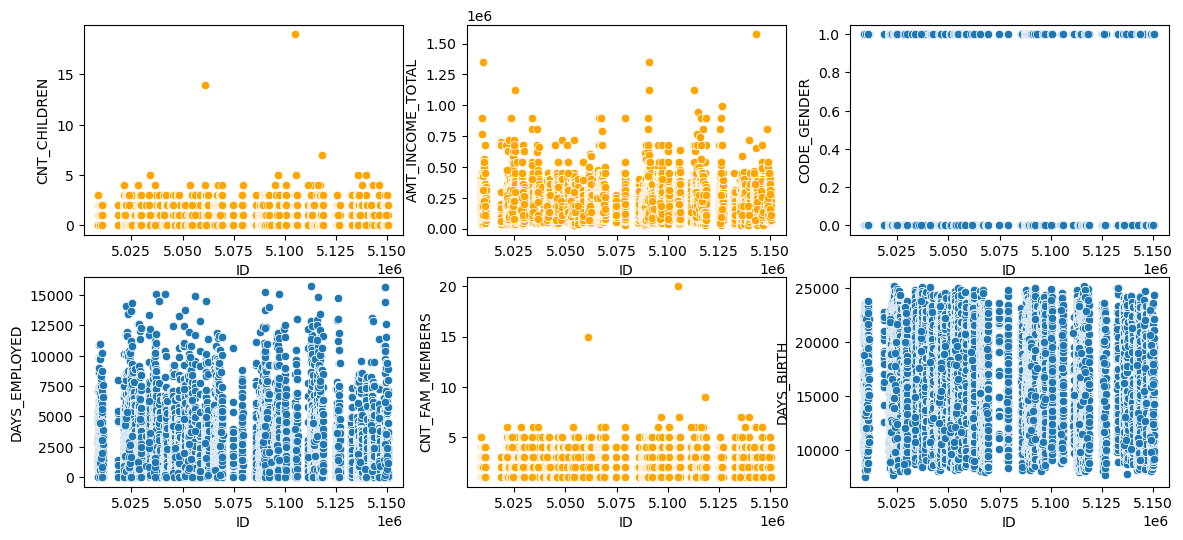

In [416]:
fig, ax= plt.subplots(nrows= 2, ncols = 3, figsize= (14,6))

sns.scatterplot(x='ID', y='CNT_CHILDREN', data=merged_df, ax=ax[0][0], color= 'orange')
sns.scatterplot(x='ID', y='AMT_INCOME_TOTAL', data=merged_df, ax=ax[0][1], color='orange')
sns.scatterplot(x='ID', y='CODE_GENDER', data=merged_df, ax=ax[0][2])
sns.scatterplot(x='ID', y='DAYS_EMPLOYED', data=merged_df, ax=ax[1][0])
sns.scatterplot(x='ID', y='CNT_FAM_MEMBERS', data=merged_df, ax=ax[1][1], color= 'orange')
sns.scatterplot(x='ID', y='DAYS_BIRTH', data=merged_df, ax=ax[1][2])

### Dealing with outliers based on interquatile range

In [417]:
# Select the columns where you want to remove outliers
columns_to_filter = ['AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS', 'CNT_CHILDREN']

# Calculate lower and upper bounds for each selected column
Q1 = merged_df[columns_to_filter].quantile(0.25)
Q3 = merged_df[columns_to_filter].quantile(0.75)
IQR = Q3-Q1
# Define the boundaries for outlier removal
lower_bound_limits = Q1 - 1.5 * (IQR)
upper_bound_limits = Q3 + 1.5 * (IQR)

# Filter out the rows containing outliers in any of the selected columns
merged_df = merged_df[~((merged_df[columns_to_filter] < lower_bound_limits) | (merged_df[columns_to_filter] > upper_bound_limits)).any(axis=1)]

In [418]:
merged_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_EDUCATION_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,...,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff
2,5008806,1,1,1,0,112500.0,2,21474,1134,2.0,...,False,False,False,False,False,False,False,True,False,False
3,5008808,0,0,1,0,270000.0,2,19110,3051,1.0,...,False,False,False,False,False,True,False,False,False,False
4,5008809,0,0,1,0,270000.0,2,19110,3051,1.0,...,False,False,False,False,False,True,False,False,False,False
5,5008810,0,0,1,0,270000.0,2,19110,3051,1.0,...,False,False,False,False,False,True,False,False,False,False
6,5008811,0,0,1,0,270000.0,2,19110,3051,1.0,...,False,False,False,False,False,True,False,False,False,False


In [419]:
len(merged_df)

34455

<Axes: xlabel='ID', ylabel='DAYS_BIRTH'>

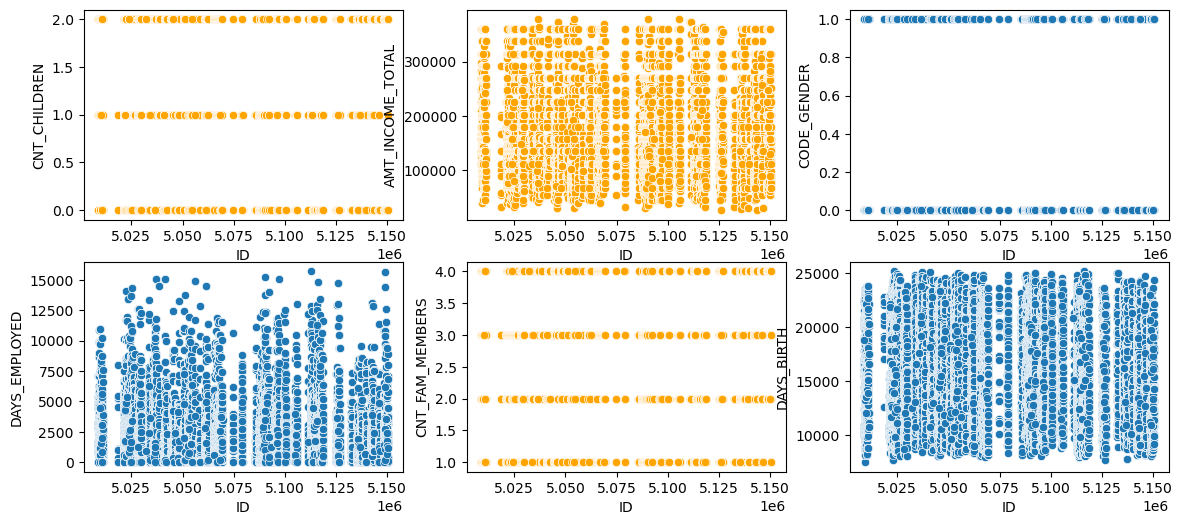

In [420]:
fig, ax= plt.subplots(nrows= 2, ncols = 3, figsize= (14,6))

sns.scatterplot(x='ID', y='CNT_CHILDREN', data=merged_df, ax=ax[0][0], color= 'orange')
sns.scatterplot(x='ID', y='AMT_INCOME_TOTAL', data=merged_df, ax=ax[0][1], color='orange')
sns.scatterplot(x='ID', y='CODE_GENDER', data=merged_df, ax=ax[0][2])
sns.scatterplot(x='ID', y='DAYS_EMPLOYED', data=merged_df, ax=ax[1][0])
sns.scatterplot(x='ID', y='CNT_FAM_MEMBERS', data=merged_df, ax=ax[1][1], color= 'orange')
sns.scatterplot(x='ID', y='DAYS_BIRTH', data=merged_df, ax=ax[1][2])

In [421]:
merged_df['DAYS_EMPLOYED'].describe()

count    34455.000000
mean      2178.838485
std       2382.478278
min          0.000000
25%        380.000000
50%       1524.000000
75%       3111.000000
max      15713.000000
Name: DAYS_EMPLOYED, dtype: float64

In [423]:
value_count = merged_df['delinquent'].value_counts(normalize = True)
value_count

delinquent
0    0.983312
1    0.016688
Name: proportion, dtype: float64

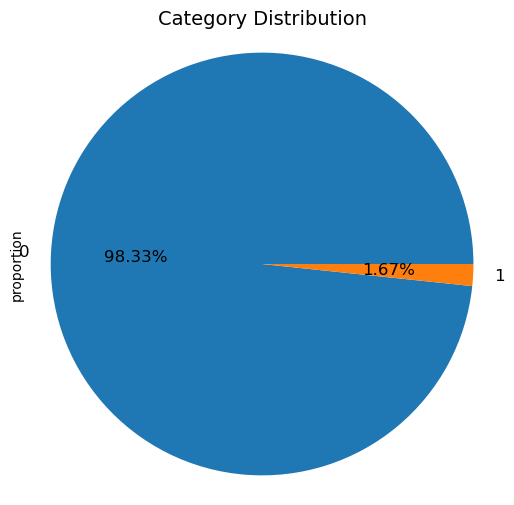

In [424]:
# Create a pie chart
value_count.plot(kind='pie', autopct='%.2f%%', figsize=(6, 6), fontsize=12)
plt.title('Category Distribution', fontsize=14)
plt.axis('equal')  # Ensure the pie chart is circular
plt.show()

In [425]:
merged_df.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_EDUCATION_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS', 'delinquent',
       'lowest_balance_months', 'Retirement_Status',
       'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant',
       'NAME_INCOME_TYPE_Student', 'NAME_INCOME_TYPE_Working',
       'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated',
       'NAME_FAMILY_STATUS_Single / not married', 'NAME_FAMILY_STATUS_Widow',
       'NAME_HOUSING_TYPE_House / apartment',
       'NAME_HOUSING_TYPE_Municipal apartment',
       'NAME_HOUSING_TYPE_Office apartment',
       'NAME_HOUSING_TYPE_Rented apartment', 'NAME_HOUSING_TYPE_With parents',
       'OCCUPATION_TYPE_Cleaning staff', 'OCCUPATION_TYPE_Cooking staff',
       'OCCUPATION_TYPE_Core staff', 'OCCUPATION_TYPE_Drivers',
       'OCCUPATION_TYPE_HR staff', 'OCCUPATION_TYPE_High skill tech staff',
       'OCCUPATION_TYPE_IT staff',

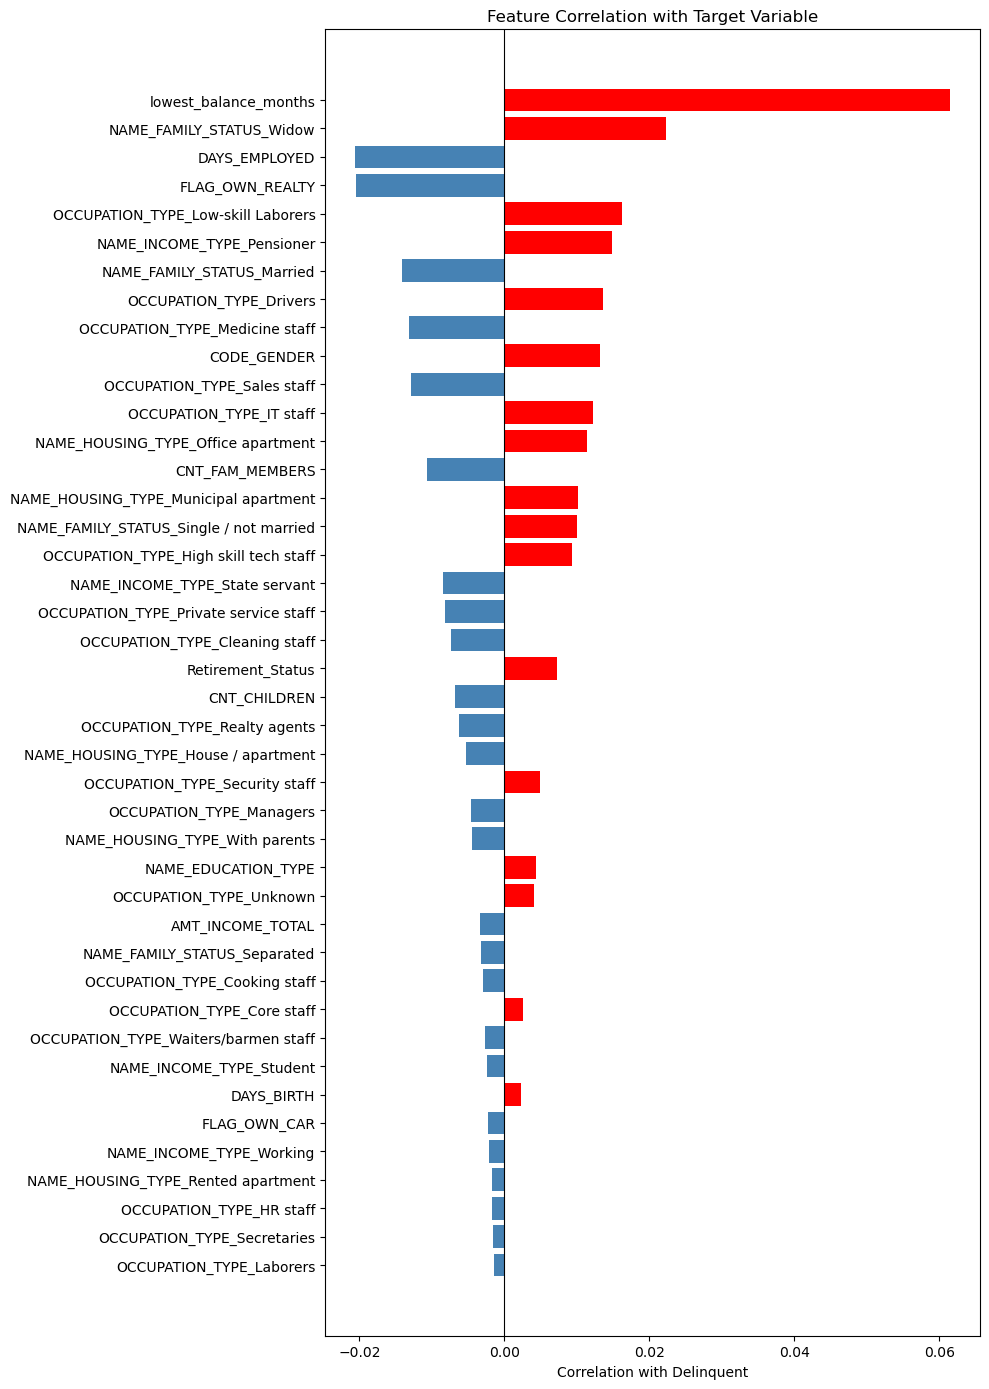

In [426]:
corr_with_target = merged_df[['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_EDUCATION_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS', 'delinquent',
       'lowest_balance_months', 'Retirement_Status',
       'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant',
       'NAME_INCOME_TYPE_Student', 'NAME_INCOME_TYPE_Working',
       'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated',
       'NAME_FAMILY_STATUS_Single / not married', 'NAME_FAMILY_STATUS_Widow',
       'NAME_HOUSING_TYPE_House / apartment',
       'NAME_HOUSING_TYPE_Municipal apartment',
       'NAME_HOUSING_TYPE_Office apartment',
       'NAME_HOUSING_TYPE_Rented apartment', 'NAME_HOUSING_TYPE_With parents',
       'OCCUPATION_TYPE_Cleaning staff', 'OCCUPATION_TYPE_Cooking staff',
       'OCCUPATION_TYPE_Core staff', 'OCCUPATION_TYPE_Drivers',
       'OCCUPATION_TYPE_HR staff', 'OCCUPATION_TYPE_High skill tech staff',
       'OCCUPATION_TYPE_IT staff', 'OCCUPATION_TYPE_Laborers',
       'OCCUPATION_TYPE_Low-skill Laborers', 'OCCUPATION_TYPE_Managers',
       'OCCUPATION_TYPE_Medicine staff',
       'OCCUPATION_TYPE_Private service staff',
       'OCCUPATION_TYPE_Realty agents', 'OCCUPATION_TYPE_Sales staff',
       'OCCUPATION_TYPE_Secretaries', 'OCCUPATION_TYPE_Security staff',
       'OCCUPATION_TYPE_Unknown', 'OCCUPATION_TYPE_Waiters/barmen staff']].corr()['delinquent'].drop('delinquent').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 14))
colors = ['red' if x > 0 else 'steelblue' for x in corr_with_target]
plt.barh(corr_with_target.index, corr_with_target.values, color=colors)
plt.xlabel('Correlation with Delinquent')
plt.title('Feature Correlation with Target Variable')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Train Test data split and dealing with over sampling data

In [460]:
X = merged_df.drop(["ID",'delinquent'], axis=1)
y = merged_df['delinquent']

In [461]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12, stratify=y)

In [462]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

X_scaled = pd.DataFrame(ss.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(ss.transform(X_test), columns=X_test.columns)

In [463]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_balanced, y_balanced = smote.fit_resample(X_scaled, y_train)

# Modeling

---



## Logistic Regression

In [477]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score


# Initialize and train the logistic regression model with regularization
logistic_model = LogisticRegression()
logistic_model.fit(X_balanced, y_balanced)

# Predict on the test set
y_pred = logistic_model.predict(X_test_scaled)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Perform cross-validation
scores = cross_val_score(logistic_model,X_balanced, y_balanced, cv=5)
print(f"Cross-validation scores: {scores}")
print(f"Average cross-validation score: {scores.mean()}")

# Print the classification report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

Accuracy: 0.6510593015381638
Cross-validation scores: [0.63750395 0.64330136 0.65011596 0.63936327 0.64326376]
Average cross-validation score: 0.6427096604403852
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.65      0.79     10164
           1       0.03      0.57      0.05       173

    accuracy                           0.65     10337
   macro avg       0.51      0.61      0.42     10337
weighted avg       0.97      0.65      0.77     10337



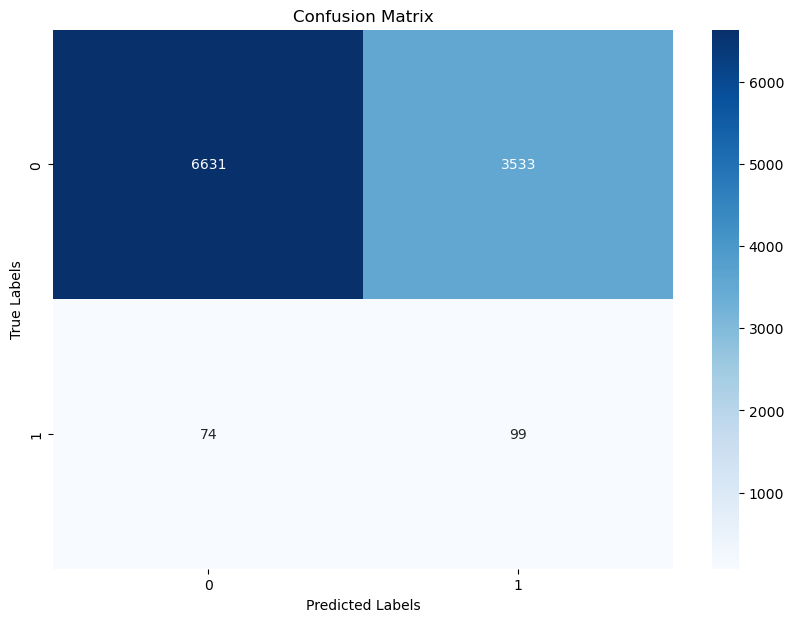

In [478]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['0','1'], yticklabels=['0','1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

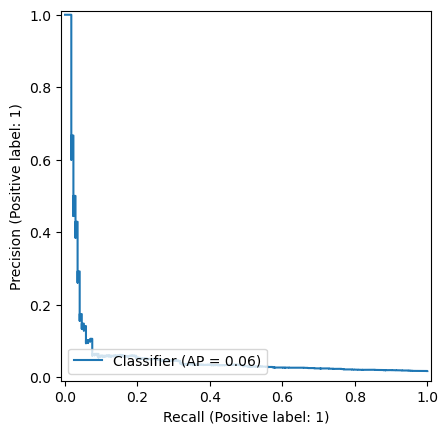

In [479]:
y_pred_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]
pr_auc_score = average_precision_score(y_test, y_pred_proba)
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba)

In [480]:
print(f"PR-AUC: {pr_auc_score:.4f}")

PR-AUC: 0.0635


## Decision Tree

In [481]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [482]:
# Initialize the Decision Tree Classifier
dtree = DecisionTreeClassifier()

# Train the model
dtree.fit(X_balanced,y_balanced)

DecisionTreeClassifier()

In [483]:
# Predictions
predictions = dtree.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, predictions))
print("Classification Report:\n", classification_report(y_test,predictions))

Accuracy: 0.9656573473928606
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98     10164
           1       0.14      0.21      0.17       173

    accuracy                           0.97     10337
   macro avg       0.56      0.59      0.58     10337
weighted avg       0.97      0.97      0.97     10337



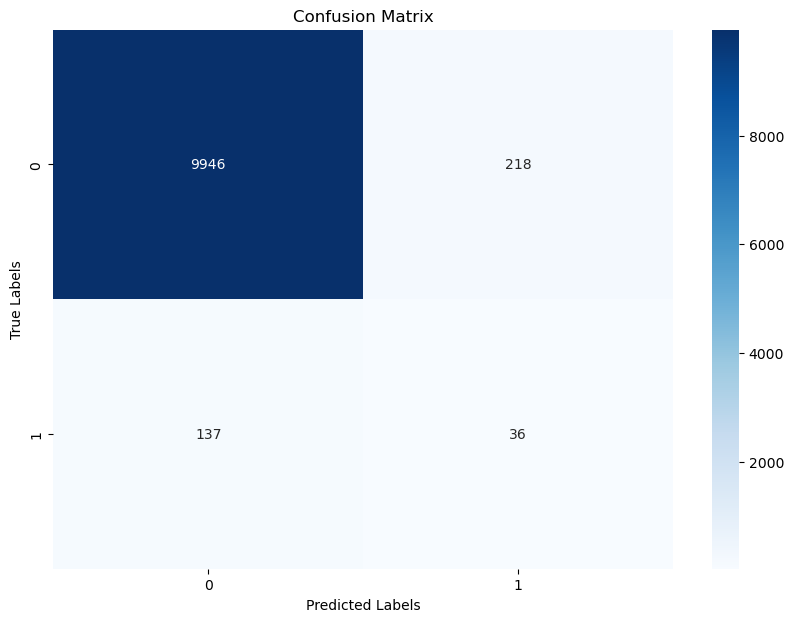

In [484]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['0','1'], yticklabels=['0','1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

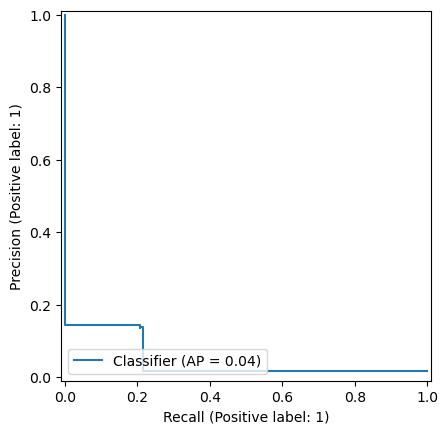

In [485]:
pred_proba = dtree.predict_proba(X_test_scaled)[:, 1]
pr_auc_score = average_precision_score(y_test, pred_proba)
PrecisionRecallDisplay.from_predictions(y_test, pred_proba)

In [486]:
print(f"PR-AUC: {pr_auc_score:.4f}")

PR-AUC: 0.0437


## Random Forest

In [487]:
from sklearn.ensemble import RandomForestClassifier

RFC = RandomForestClassifier()

RFC.fit(X_balanced,y_balanced)

y_predict = RFC.predict(X_test_scaled)
print("RandomForest Test Accuracy = " , accuracy_score(y_test, y_predict))
print("Classification Report:\n", classification_report(y_test,y_predict))

RandomForest Test Accuracy =  0.9787172293702234
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     10164
           1       0.31      0.22      0.26       173

    accuracy                           0.98     10337
   macro avg       0.65      0.61      0.62     10337
weighted avg       0.98      0.98      0.98     10337



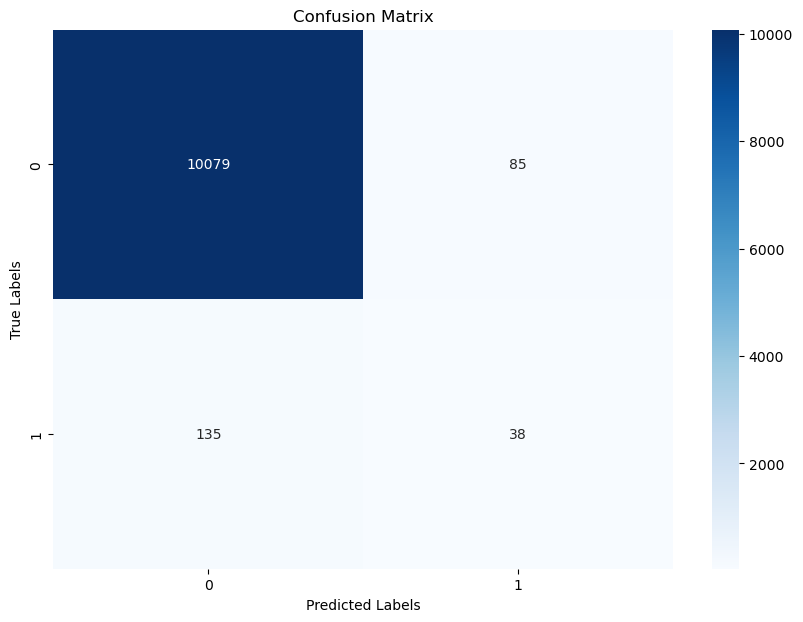

In [488]:
cm = confusion_matrix(y_test, y_predict)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['0','1'], yticklabels=['0','1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

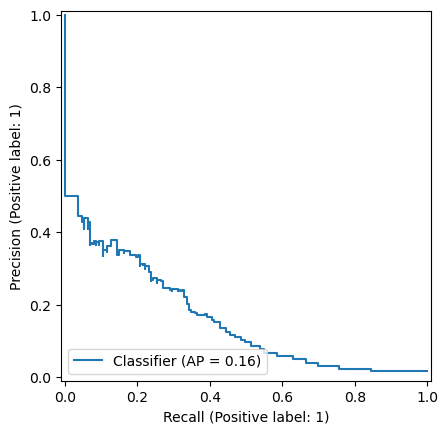

In [489]:
y_predict_proba = RFC.predict_proba(X_test_scaled)[:, 1]
pr_auc_score = average_precision_score(y_test, y_predict_proba)
PrecisionRecallDisplay.from_predictions(y_test, y_predict_proba)

In [490]:
print(f"PR-AUC: {pr_auc_score:.4f}")

PR-AUC: 0.1585


In [491]:
# train accuracy
y_train_predict = RFC.predict(X_balanced)
print("RandomForest Train Accuracy = " , accuracy_score(y_balanced, y_train_predict))

RandomForest Train Accuracy =  0.9991777702816664


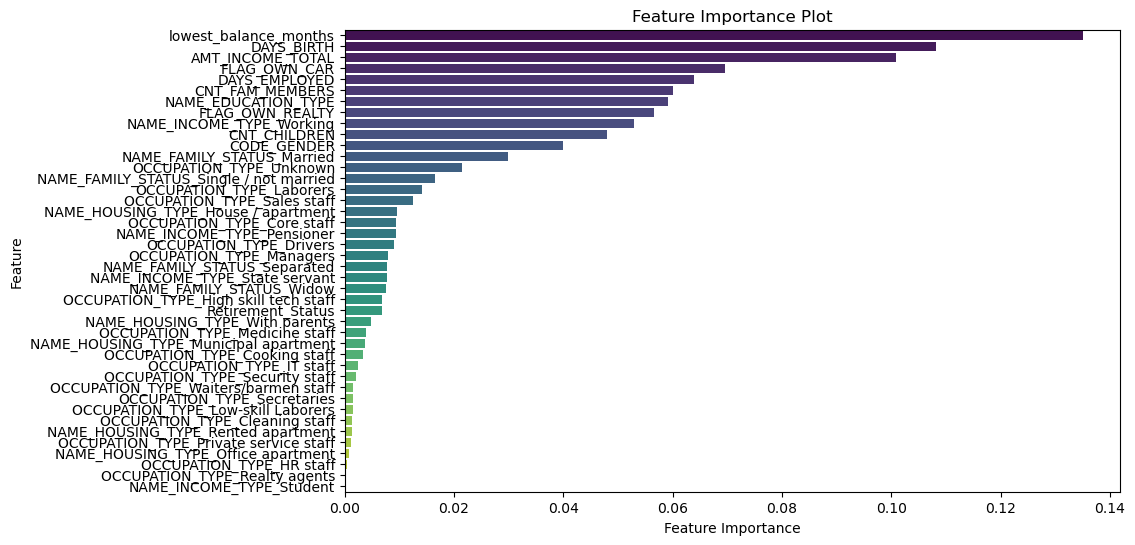

In [492]:
feat_importances = RFC.feature_importances_

# Create a pandas Series with feature importances
feat_importances_series = pd.Series(feat_importances, index=X.columns)

# Sort feature importances in descending order
feat_importances_series = feat_importances_series.sort_values(ascending=False)

# feat_importances_series = feat_importances_series[:6]

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importances_series.values, y=feat_importances_series.index, palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance Plot')
plt.show()


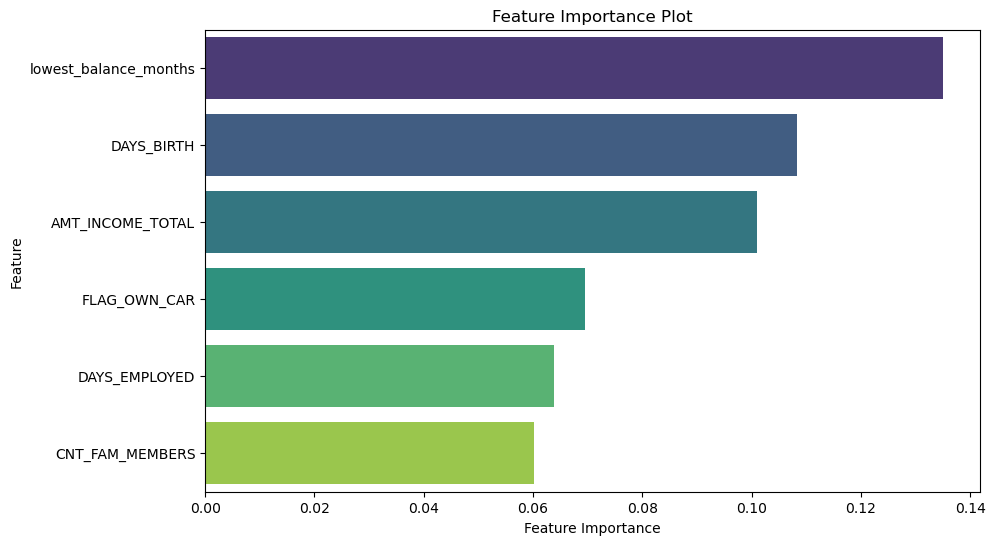

In [493]:
# Top 6 feature importance

feat_importances_series = feat_importances_series[:6]

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importances_series.values, y=feat_importances_series.index, palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance Plot')
plt.show()


### Lets calculate the cost it would inqure a company if a defaulter is approved vs if person is wrongly rejected

In [ ]:
# Assuming a missed default costs $500 and a wrong rejection costs $50, assuming 10x rate for a missed default, the model cost would be
FN_cost = 500
FP_cost = 50
FN = cm[1][0]  # False Negatives
FP = cm[0][1]  # False Positives

model_cost = (FN_cost * FN) + (FP_cost * FP)
print(f"Model Cost: ${model_cost}")

Model Cost: $71750


In [495]:
# Calculating two baselines where 1) Approve Everyone and 2) Reject Everyone. The cost of each baseline is calculated based on the number of false negatives and false positives, multiplied by their respective costs. This provides a benchmark to compare the model's performance against simple strategies.

# Baseline 1: Approve Everyone
# In this case, all applicants are approved, so there are no false positives, but all defaults are missed.
baseline1_cost = (FN_cost * (cm[1][0] + cm[1][1])) + (FP_cost * 0)
print(f"Baseline 1 (Approve Everyone) Cost: ${baseline1_cost}")

# Baseline 2: Reject Everyone
# In this case, all applicants are rejected, so there are no false negatives, but all legitimate applicants are rejected.
baseline2_cost = (FN_cost * 0) + (FP_cost * (cm[0][0] + cm[0][1]))
print(f"Baseline 2 (Reject Everyone) Cost: ${baseline2_cost}")

Baseline 1 (Approve Everyone) Cost: $86500
Baseline 2 (Reject Everyone) Cost: $508200


#### Based on the comparison between both baseline and the model cost, as it is lower, it shows that the model actually add value to the predictions. 

### Checking the results with varied threshold value

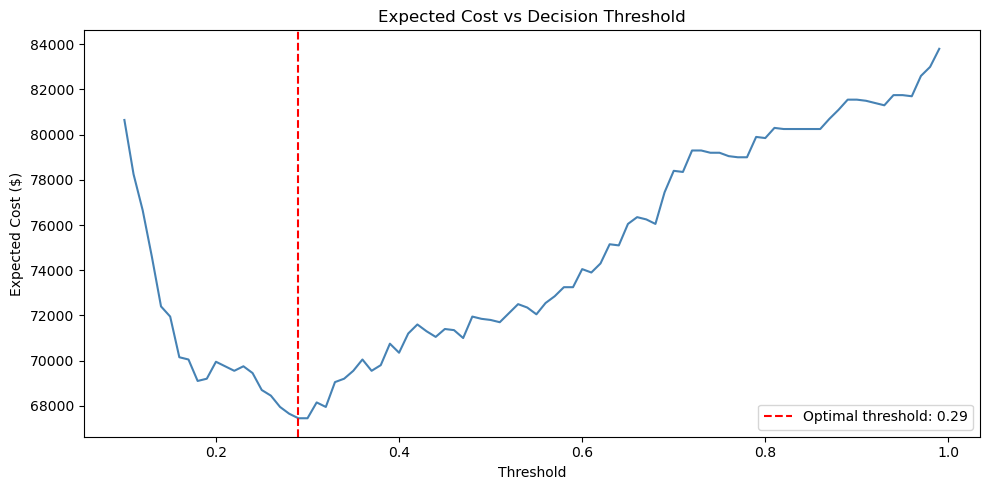

Optimal Threshold: 0.29
Minimum Expected Cost: $67,450
Cost at 0.5 threshold: $73,250
Savings vs default threshold: $5,800


In [ ]:
thresholds = np.arange(0.01, 1.0, 0.01)
costs = []

for threshold in thresholds:
    y_pred_thresh = (y_predict_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    cost = (fn * FN_cost) + (fp * FP_cost)
    costs.append(cost)

optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs, color='steelblue')
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal threshold: {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Expected Cost ($)')
plt.title('Expected Cost vs Decision Threshold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Minimum Expected Cost: ${optimal_cost:,.0f}")
print(f"Cost at 0.5 threshold: ${costs[49]:,.0f}")
print(f"Savings vs default threshold: ${costs[49] - optimal_cost:,.0f}")

Accuracy at optimal threshold: 0.9705


<Axes: >

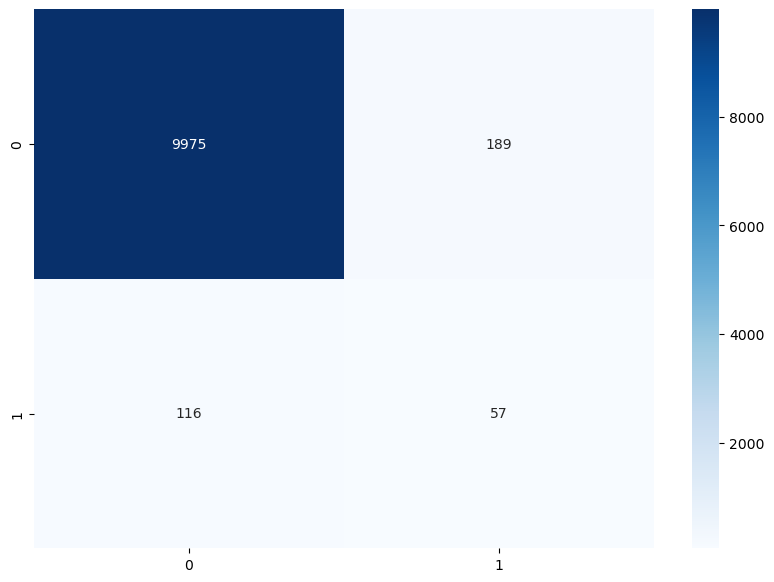

In [500]:
# Checking RFC results with optimal threshold

y_pred_optimal = (y_predict_proba >= optimal_threshold).astype(int)

accuracy_optimal = accuracy_score(y_test, y_pred_optimal)
print(f"Accuracy at optimal threshold: {accuracy_optimal:.4f}")

confusion_matrix_optimal = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix_optimal, annot=True, fmt="d", cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])    

## Experimenting with LightGBM model

In [515]:
# SMOTE is not required for LightGBM model as it can handle imbalanced datasets effectively. LightGBM uses a gradient boosting framework that can focus on the harder-to-classify samples, making it robust to class imbalance without the need for oversampling techniques like SMOTE.

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgbm_model = lgb.LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=15)
lgbm_model.fit(X_scaled, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 402, number of negative: 23716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002428 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 844
[LightGBM] [Info] Number of data points in the train set: 24118, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016668 -> initscore=-4.077453
[LightGBM] [Info] Start training from score -4.077453


LGBMClassifier(random_state=15, scale_pos_weight=58.995024875621894)

In [516]:
y_predict_lgmb = lgbm_model.predict(X_test_scaled)
print("LightGBM Test Accuracy = " , accuracy_score(y_test, y_predict_lgmb))

LightGBM Test Accuracy =  0.9235755054658025


In [517]:
y_predict_train_lgbm = lgbm_model.predict(X_scaled)
print("LightGBM Train Accuracy = " , accuracy_score(y_train, y_predict_train_lgbm))

LightGBM Train Accuracy =  0.9468861431296127


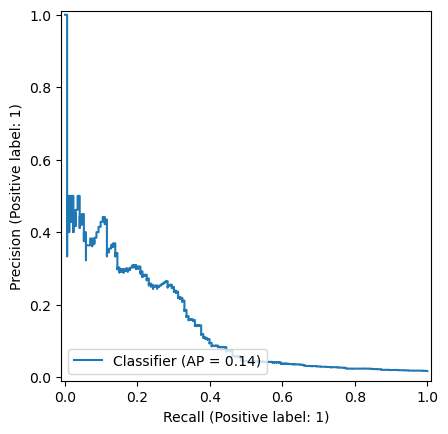

In [518]:
y_predict_proba_lgbm = lgbm_model.predict_proba(X_test_scaled)[:, 1]
pr_auc_score = average_precision_score(y_test, y_predict_proba_lgbm)
PrecisionRecallDisplay.from_predictions(y_test, y_predict_proba_lgbm)

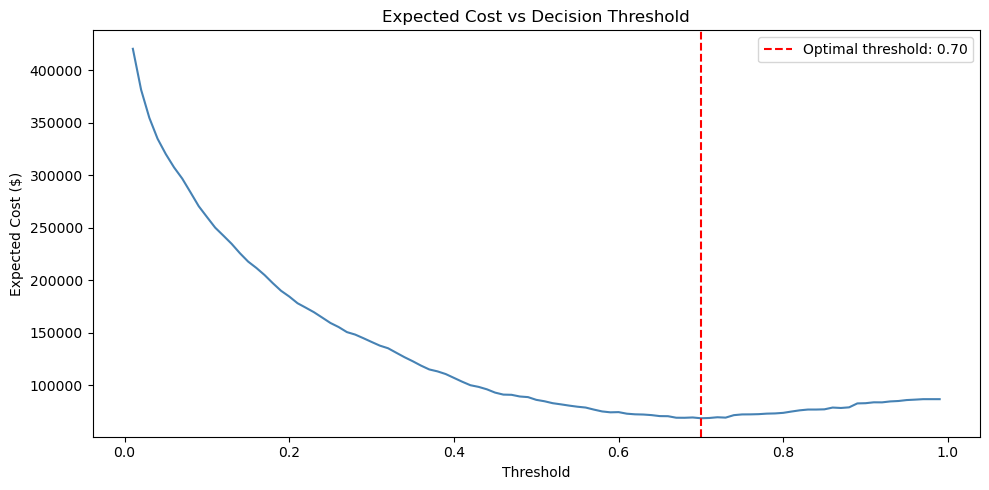

Optimal Threshold: 0.70
Minimum Expected Cost: $68,300
Cost at 0.5 threshold: $85,850
Savings vs default threshold: $17,550


In [519]:
thresholds = np.arange(0.01, 1.0, 0.01)
costs = []

for threshold in thresholds:
    y_pred_thresh = (y_predict_proba_lgbm >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    cost = (fn * FN_cost) + (fp * FP_cost)
    costs.append(cost)

optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs, color='steelblue')
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal threshold: {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Expected Cost ($)')
plt.title('Expected Cost vs Decision Threshold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Minimum Expected Cost: ${optimal_cost:,.0f}")
print(f"Cost at 0.5 threshold: ${costs[49]:,.0f}")
print(f"Savings vs default threshold: ${costs[49] - optimal_cost:,.0f}")

Accuracy at optimal threshold: 0.9715


<Axes: >

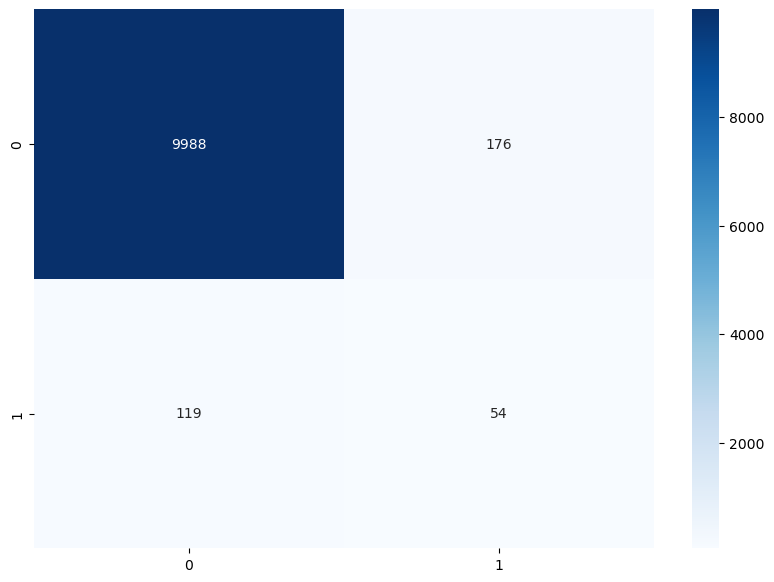

In [520]:
# Checking LGBM results with optimal threshold

y_pred_optimal = (y_predict_proba_lgbm >= optimal_threshold).astype(int)

accuracy_optimal = accuracy_score(y_test, y_pred_optimal)
print(f"Accuracy at optimal threshold: {accuracy_optimal:.4f}")

confusion_matrix_optimal = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix_optimal, annot=True, fmt="d", cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])    

In [521]:
print(f"PR-AUC: {pr_auc_score:.4f}")

PR-AUC: 0.1446


## Testing out the response of XGBoost on this dataset

XGBoost Test Accuracy =  0.963432330463384
XGBoost Test AUC-PR =  0.2045301732776391


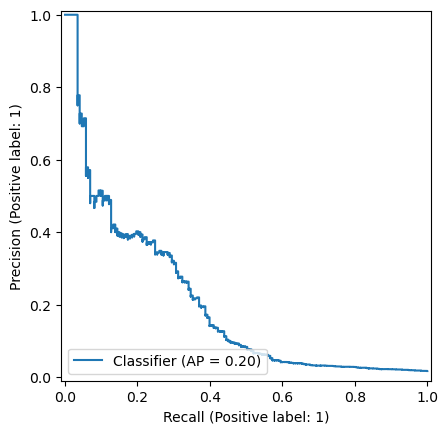

In [538]:
xgb_model = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=15, eval_metric = 'aucpr')
xgb_model.fit(X_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
print("XGBoost Test Accuracy = " , accuracy_score(y_test, y_pred_xgb))  

y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
pr_auc_score_xgb = average_precision_score(y_test, y_pred_proba_xgb)
print("XGBoost Test AUC-PR = ", pr_auc_score_xgb)

PrecisionRecallDisplay.from_predictions(y_test, y_predict_proba_xgb)

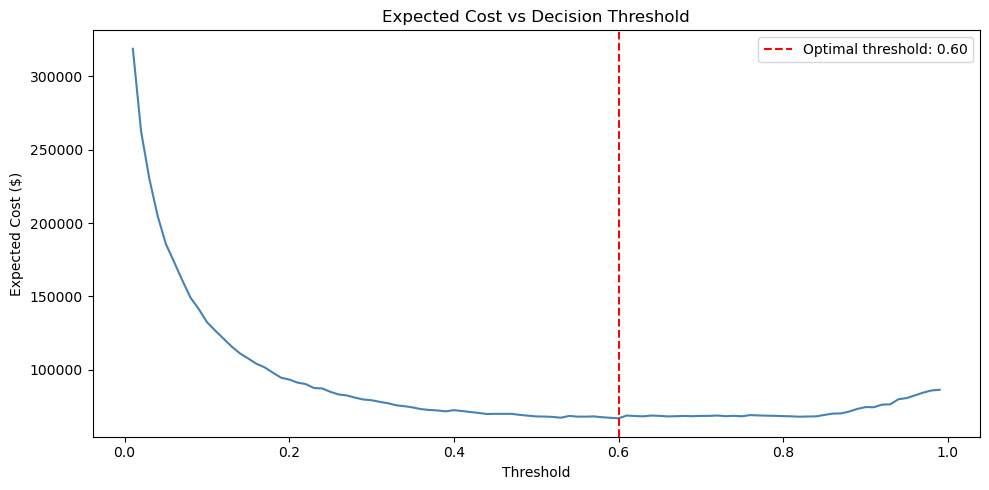

Optimal Threshold: 0.60
Minimum Expected Cost: $67,150
Cost at 0.5 threshold: $68,400
Savings vs default threshold: $1,250


In [539]:
thresholds = np.arange(0.01, 1.0, 0.01)
costs = []

for threshold in thresholds:
    y_pred_thresh = (y_pred_proba_xgb >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    cost = (fn * FN_cost) + (fp * FP_cost)
    costs.append(cost)

optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs, color='steelblue')
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal threshold: {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Expected Cost ($)')
plt.title('Expected Cost vs Decision Threshold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Minimum Expected Cost: ${optimal_cost:,.0f}")
print(f"Cost at 0.5 threshold: ${costs[49]:,.0f}")
print(f"Savings vs default threshold: ${costs[49] - optimal_cost:,.0f}")

In [543]:
# Hyperparameter tuning for XGBoost using GridSearchCV to find the best combination of hyperparameters that maximizes the model's performance. This process involves testing different values for parameters such as learning rate, max depth, and number of estimators to optimize the model's predictive accuracy and minimize the expected cost.

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_grid,
                            n_iter=30, scoring='average_precision', cv=5,
                            verbose=1, random_state=42, n_jobs=-1)

search.fit(X_scaled, y_train)

print(f"Best PR-AUC (CV): {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

best_xgb = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best PR-AUC (CV): 0.1656
Best params: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.6}


PR-AUC: 0.2189


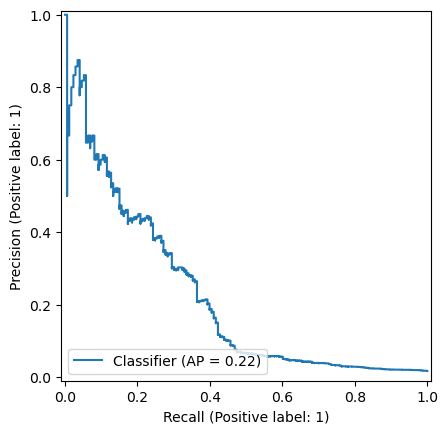

In [544]:
y_predict_proba_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]
pr_auc_score = average_precision_score(y_test, y_predict_proba_xgb)
print(f"PR-AUC: {pr_auc_score:.4f}")
PrecisionRecallDisplay.from_predictions(y_test, y_predict_proba_xgb)

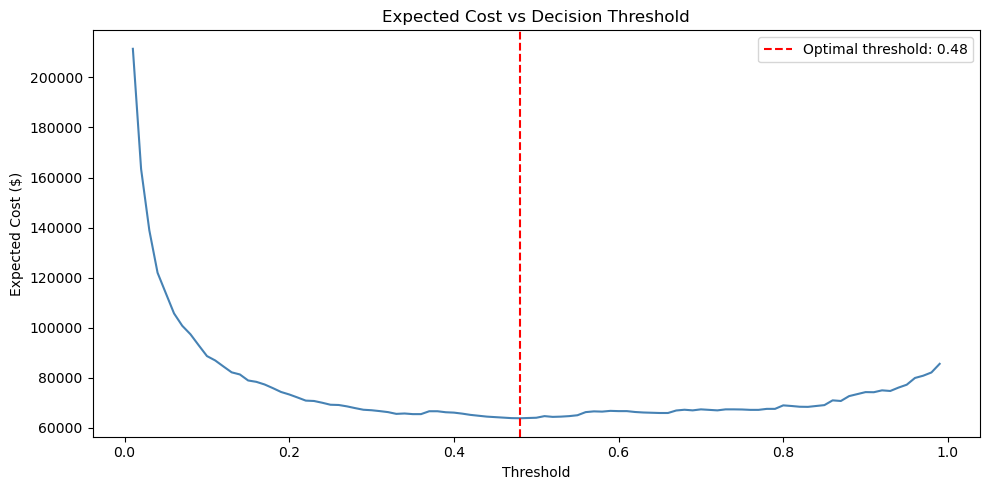

Optimal Threshold: 0.48
Minimum Expected Cost: $63,800
Cost at 0.5 threshold: $64,000
Savings vs default threshold: $200


In [553]:
thresholds = np.arange(0.01, 1.0, 0.01)
costs = []

for threshold in thresholds:
    y_pred_thresh = (y_predict_proba_xgb >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    cost = (fn * FN_cost) + (fp * FP_cost)
    costs.append(cost)

optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs, color='steelblue')
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal threshold: {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Expected Cost ($)')
plt.title('Expected Cost vs Decision Threshold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Minimum Expected Cost: ${optimal_cost:,.0f}")
print(f"Cost at 0.5 threshold: ${costs[49]:,.0f}")
print(f"Savings vs default threshold: ${costs[49] - optimal_cost:,.0f}")

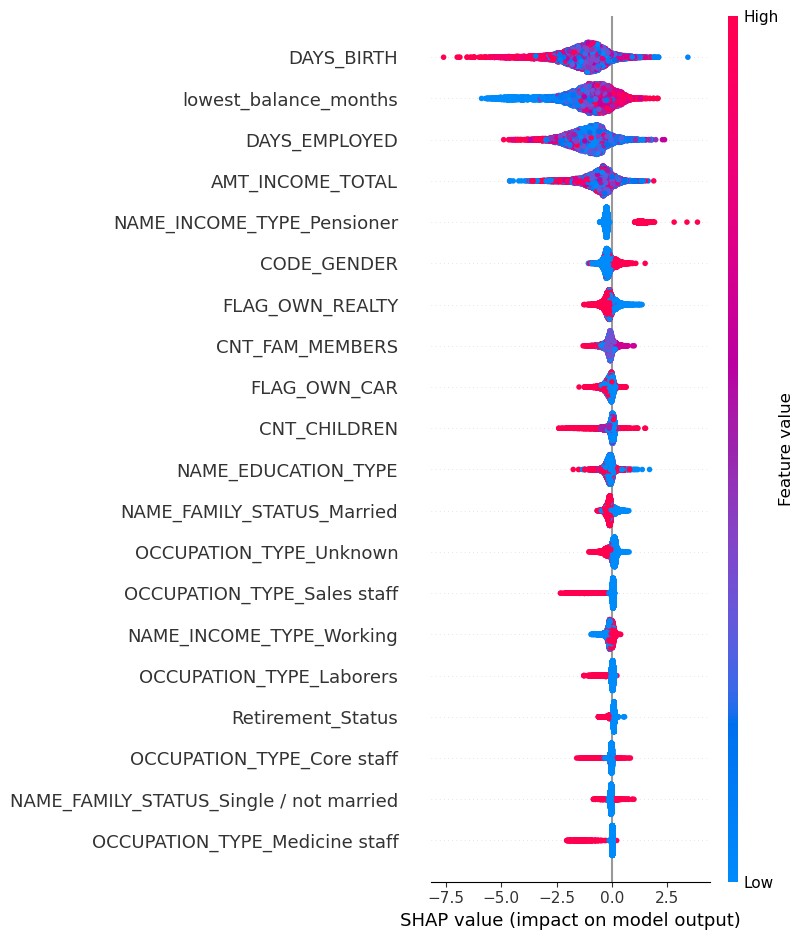

In [551]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot — global feature importance
shap.summary_plot(shap_values, X_test_scaled)

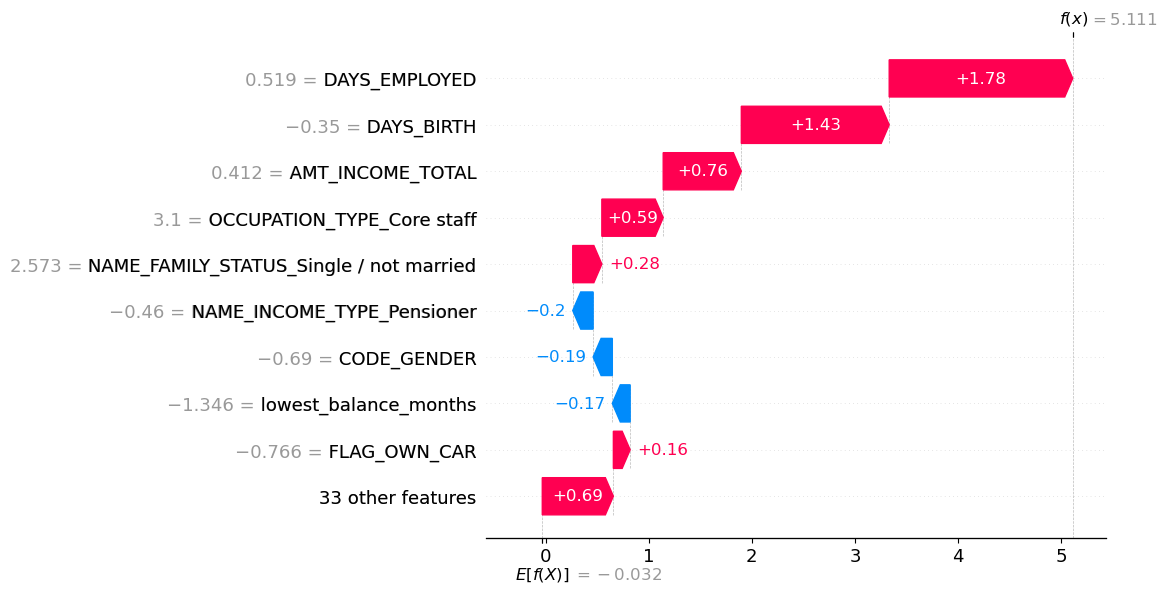

In [ ]:
high_risk_idx = y_predict_proba_xgb.argmax()

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_scaled.iloc[high_risk_idx],
        feature_names=X_test_scaled.columns.tolist()
    )
)